## Midterm project: Equity Portfolio Management

### 1.	Lohith Reddy Tamma (lt268)
### 2.  Achutha Sreenivas Mullapudi (am3687)
### 3.  Vijaya Sravani Balemarthi (vb467)

In [1]:
# Loading the required libraries
library(dplyr)
library(ggplot2)
library(grid)
library(reshape2)
library(gridExtra)
library(gtable)
library(plotly)
library(lubridate)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [2]:
library(tidyquant)

# Define your stock universe
universe <- c('IBM', 'MSFT', 'GOOG', 'AAPL', 'AMZN', 'META', 'NFLX', 'TSLA', 'ORCL', 'SAP')

# Now set the date range for given historical data
start_date <- '2018-01-01'
end_date <- '2018-12-31'

for (stock in universe) {
  stock_data <- tq_get(stock, from = start_date, to = end_date, get = "stock.prices")
  file_name <- paste0(stock, ".csv")
  write.csv(stock_data, file_name, row.names = FALSE)
  cat(paste("Stock", stock, "data saved as", file_name, "\n"))
}

Warning message:
“package ‘tidyquant’ was built under R version 4.3.3”
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

── Attaching core tidyquant packages ──────────────────────── tidyquant 1.0.9 ──
✔ PerformanceAnalytics 2.0.4      ✔ TTR                  0.24.4
✔ quantmod             0.4.26     ✔ xts                  0.13.2
── Conflicts ────────────────────────────────────────── tidyquant_conflicts() ──
✖ zoo::as.Date()                 masks base::as.Date()
✖ zoo::as.Date.numeric()         masks base::as.Date.numeric()
✖ gridExtra::combine()           masks dplyr::combine()
✖ plotly::filter()               masks dplyr::filter(), stats::filter()
✖ xts::first()                   masks dplyr::first()
✖ dplyr::lag()                   masks stats::lag()
✖ xts::last()                    masks dplyr::last()
✖ PerformanceAnalytics::legend() masks graphics::legend()
✖ quantmod::summary()            masks base::summary()
ℹ Use the conflicted p

Stock IBM data saved as IBM.csv 
Stock MSFT data saved as MSFT.csv 
Stock GOOG data saved as GOOG.csv 
Stock AAPL data saved as AAPL.csv 
Stock AMZN data saved as AMZN.csv 
Stock META data saved as META.csv 
Stock NFLX data saved as NFLX.csv 
Stock TSLA data saved as TSLA.csv 
Stock ORCL data saved as ORCL.csv 
Stock SAP data saved as SAP.csv 


In [3]:
IBM <- read.csv('IBM.csv')
MSFT <- read.csv('MSFT.csv')
GOOG <- read.csv('GOOG.csv')
AMZN <- read.csv('AMZN.csv')
AAPL <- read.csv('AAPL.csv')
FB <- read.csv('META.csv')
NFLX <- read.csv('NFLX.csv')
TSLA <- read.csv('TSLA.csv')
ORCL <- read.csv('ORCL.csv')
SAP <- read.csv('SAP.csv')

cat('IBM Data:\n')
head(IBM)
cat('Microsoft Data:\n')
head(MSFT)
cat('Amazon Data:\n')
head(GOOG)
cat('Google Data:\n')
head(AMZN)
cat('Apple Data:\n')
head(AAPL)
cat('Facebook Data:\n')
head(FB)
cat('Netflix Data:\n')
head(NFLX)
cat('Oracle Data:\n')
head(ORCL)
cat('SAP Data:\n')
head(SAP)
cat('Tesla Data:\n')
head(TSLA)

IBM Data:


,symbol,date,open,high,low,close,volume,adjusted
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,IBM,2018-01-02,147.7056,148.0019,146.7878,147.4665,4395815,107.5304
2,IBM,2018-01-03,150.4207,152.7820,149.4551,151.5201,9875914,110.4862
3,IBM,2018-01-04,152.6291,155.1816,152.3614,154.5889,7903785,112.7239
4,IBM,2018-01-05,155.2964,155.7361,154.0153,155.3442,5434807,113.2747
5,IBM,2018-01-08,155.5067,156.7017,154.5889,156.2811,5478425,113.9578
6,IBM,2018-01-09,156.6922,157.2944,155.8891,156.6252,4541523,114.2088


Microsoft Data:


,symbol,date,open,high,low,close,volume,adjusted
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,MSFT,2018-01-02,86.13,86.31,85.50,85.95,22483800,79.79292
2,MSFT,2018-01-03,86.06,86.51,85.97,86.35,26061400,80.16427
3,MSFT,2018-01-04,86.59,87.66,86.57,87.11,21912000,80.86981
4,MSFT,2018-01-05,87.66,88.41,87.43,88.19,23407100,81.87245
5,MSFT,2018-01-08,88.20,88.58,87.60,88.28,22113000,81.95601
6,MSFT,2018-01-09,88.65,88.73,87.86,88.22,19484300,81.90033


Amazon Data:


...

,symbol,date,open,high,low,close,volume,adjusted
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,ORCL,2018-01-02,47.57,47.80,46.17,46.63,25380000,41.77161
2,ORCL,2018-01-03,47.53,48.07,47.44,47.71,24165000,42.73909
3,ORCL,2018-01-04,47.99,48.19,47.72,48.18,19815100,43.16013
4,ORCL,2018-01-05,48.42,48.63,48.28,48.47,14496400,43.41991
5,ORCL,2018-01-08,48.30,49.07,47.94,48.98,15075000,43.87677
6,ORCL,2018-01-09,49.25,49.36,48.92,49.06,14153700,44.11959


SAP Data:


,symbol,date,open,high,low,close,volume,adjusted
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,SAP,2018-01-02,111.23,112.42,111.13,112.39,540600,99.95593
2,SAP,2018-01-03,112.63,113.69,112.55,113.31,506200,100.77415
3,SAP,2018-01-04,114.78,115.30,114.70,115.05,539300,102.32166
4,SAP,2018-01-05,115.45,116.50,115.36,116.33,475300,103.46004
5,SAP,2018-01-08,115.09,115.42,114.76,114.80,515400,102.09932
6,SAP,2018-01-09,114.36,114.46,113.45,114.16,515900,101.53012


Tesla Data:


,symbol,date,open,high,low,close,volume,adjusted
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TSLA,2018-01-02,20.80000,21.47400,20.73333,21.36867,65283000,21.36867
2,TSLA,2018-01-03,21.40000,21.68333,21.03667,21.15000,67822500,21.15000
3,TSLA,2018-01-04,20.85800,21.23667,20.37867,20.97467,149194500,20.97467
4,TSLA,2018-01-05,21.10800,21.14933,20.80000,21.10533,68868000,21.10533
5,TSLA,2018-01-08,21.06667,22.46800,21.03333,22.42733,147891000,22.42733
6,TSLA,2018-01-09,22.34400,22.58667,21.82667,22.24600,107199000,22.24600


## Obtaining the "Close" and "Adjusted Close" figures for every stock

In [4]:
universe <- c("IBM.csv", "MSFT.csv", "GOOG.csv", "AAPL.csv", "AMZN.csv", "META.csv", "NFLX.csv", "ORCL.csv", "SAP.csv", "TSLA.csv")

dfs <- lapply(universe, function(file) {
  read.csv(file, header = TRUE, stringsAsFactors = FALSE)
})

close_adjusted <- lapply(dfs, function(df) {
  if ("close" %in% colnames(df) && "adjusted" %in% colnames(df)) {
    df[, c("close", "adjusted")]
  } else {
    NULL  
  }
})

close_adjusted <- Filter(function(x) !is.null(x), close_adjusted)

if (length(close_adjusted) == 0) {
  stop("No data frames with 'close' and 'adjusted' columns found.")
}

stock_names <- gsub(".csv", "", universe)

Close_AdjClose_df <- do.call(cbind, close_adjusted)

Date <- dfs[[1]]$date
                              
Close_AdjClose_df <- cbind(Date, Close_AdjClose_df)

colnames(Close_AdjClose_df) <- c("Date", paste(rep(stock_names, each = 2), c("Close", "AdjClose"), sep = "_"))

Stocks <- Close_AdjClose_df

head(Stocks)

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,META_Close,META_AdjClose,NFLX_Close,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.4665,107.5304,85.95,79.79292,53.2500,53.11955,43.0650,40.56894,59.4505,⋯,181.42,180.8754,201.07,201.07,46.63,41.77161,112.39,99.95593,21.36867,21.36867
2,2018-01-03,151.5201,110.4862,86.35,80.16427,54.1240,53.99141,43.0575,40.56187,60.2100,⋯,184.67,184.1157,205.05,205.05,47.71,42.73909,113.31,100.77415,21.15000,21.15000
3,2018-01-04,154.5889,112.7239,87.11,80.86981,54.3200,54.18693,43.2575,40.75027,60.4795,⋯,184.33,183.7767,205.63,205.63,48.18,43.16013,115.05,102.32166,20.97467,20.97467
4,2018-01-05,155.3442,113.2747,88.19,81.87245,55.1115,54.97649,43.7500,41.21423,61.4570,⋯,186.85,186.2891,209.99,209.99,48.47,43.41991,116.33,103.46004,21.10533,21.10533
5,2018-01-08,156.2811,113.9578,88.28,81.95601,55.3470,55.21141,43.5875,41.06114,62.3435,⋯,188.28,187.7148,212.05,212.05,48.98,43.87677,114.80,102.09932,22.42733,22.42733
6,2018-01-09,156.6252,114.2088,88.22,81.90033,55.3130,55.17749,43.5825,41.05644,62.6350,⋯,187.87,187.3060,209.31,209.31,49.06,44.11959,114.16,101.53012,22.24600,22.24600


## 1.
On Jan 02 2018, you split the 5 million dollars into 5 one million dollars, and use them to buy 5 stocks from the 10 stocks. For example, IBM close price was 154.25 dollars. With 1 million dollars, you can buy a maximum of 6482 shares with a cost of 999,848.5 dollars, leaving you with 151.5 dollars in cash. You decided to spend 1 million dollars on each of ['IBM', 'MSFT', 'GOOG', 'AAPL', 'AMZN'] respectively and keep the rest of the cash in a zero-interest cash account. On Jan 02 2018, your mark to market value (MTM) is 5 million dollars when combining all stocks' value and cash. Your holdings of stocks and cash account make up your portfolio.

In [5]:
split = Stocks[seq(1,nrow(Stocks),5),]
split$Date = as.Date(split$Date)

split[split$Date=='2018-01-02',]

a = split[split$Date=='2018-01-02',
                  c('IBM_Close','MSFT_Close','GOOG_Close','AAPL_Close','AMZN_Close')]

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,META_Close,META_AdjClose,NFLX_Close,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.4665,107.5304,85.95,79.79292,53.25,53.11955,43.065,40.56894,59.4505,⋯,181.42,180.8754,201.07,201.07,46.63,41.77161,112.39,99.95593,21.36867,21.36867


In [6]:
# Set initial investment and display precision for numeric values
total_investment <- 5000000
options(digits = 9)
remaining_cash <- total_investment
investment_split <- total_investment / 5
mark_to_market <- 0

# Define start, end, and initial investment dates
start_date <- mdy('01/02/2018')
initial_investment_date <- mdy('01/02/2018')
end_date <- mdy('12/31/2018')

# List of all stocks (Adjusted Close prices)
AllStocks <- c('IBM_AdjClose', 'MSFT_AdjClose', 'GOOG_AdjClose', 'AAPL_AdjClose', 'AMZN_AdjClose', 
               'META_AdjClose', 'NFLX_AdjClose', 'TSLA_AdjClose', 'ORCL_AdjClose', 'SAP_AdjClose')

# List of initial stocks (Closing prices)
InitialStocks <- c('IBM_Close', 'MSFT_Close', 'GOOG_Close', 'AAPL_Close', 'AMZN_Close')
shares_bought <- list()  # Initialize empty list to store shares bought

# Main loop: iterate through each day from start_date to end_date
while (start_date <= end_date) {
  # For initial investment day (January 2, 2018)
  if (start_date == mdy('01/02/2018')) {
    for (i in InitialStocks) {
      a <- Stocks[Stocks$Date == start_date, InitialStocks]  # Fetch stock prices for the day
      b <- floor(investment_split / a[i])  # Calculate number of shares to buy
      shares_bought[i] <- b[[i]]  # Store number of shares bought
      remaining_cash <- remaining_cash - b * a[i]  # Update remaining cash
      mark_to_market <- mark_to_market + b * a[i]  # Update mark-to-market value
    }
    
    # Store remaining cash and mark-to-market values for that day
    colnames(remaining_cash) <- 'remaining_cash'
    Stocks[Stocks$Date == start_date, 'remaining_cash'] <- remaining_cash
    colnames(mark_to_market) <- 'mark_to_market'
    mark_to_market <- mark_to_market + remaining_cash
    Stocks[Stocks$Date == start_date, 'mark_to_market'] <- mark_to_market
  }
  
  # For stock split dates
  else if (start_date %in% split$Date) {
    mark_to_market <- 0  # Reset mark-to-market value
    for (i in InitialStocks) {
      a <- Stocks[Stocks$Date == start_date, InitialStocks]  # Fetch stock prices for the split day
      mark_to_market <- mark_to_market + shares_bought[[i]] * a[i]  # Recalculate mark-to-market value
    }
    
    # Update total investment and split the cash
    total_investment <- mark_to_market + remaining_cash
    remaining_cash <- total_investment
    investment_split <- total_investment / 5
    colnames(total_investment) <- 'total_investment'
    colnames(mark_to_market) <- 'mark_to_market'
    
    # Calculate stock performance based on percentage change since initial investment
    calculated_stocks <- list()
    for (i in AllStocks) {
      x <- Stocks[Stocks$Date == start_date, AllStocks]  # Fetch current stock prices
      y <- Stocks[Stocks$Date == initial_investment_date, AllStocks]  # Fetch initial stock prices
      percent_change <- 100 * ((x[i] - y[i]) / y[i])  # Calculate percentage change
      col <- paste0(i, "_PC")  # Create a new column for percentage change
      calculated_stocks[col] <- percent_change  # Store percentage change
    }
    
    # Sort by percentage change and select the top 5 stocks for reinvestment
    calculated_stocks <- calculated_stocks[order(unlist(calculated_stocks))]
    calculated_stocks <- head(calculated_stocks, 5)
    
    # Update the list of initial stocks based on top performers
    initial_col_list <- names(calculated_stocks)
    initial_col_list <- sub('_.*', '', initial_col_list)
    initial_col_list <- paste0(initial_col_list, '_Close')
    InitialStocks <- initial_col_list
    shares_bought <- list()  # Reset shares bought
    mark_to_market <- 0  # Reset mark-to-market
    
    # Reinvest in top 5 stocks after split
    for (i in InitialStocks) {
      a <- Stocks[Stocks$Date == start_date, InitialStocks]  # Fetch current prices
      b <- floor(investment_split[, 1] / a[i])  # Calculate shares to buy
      shares_bought[i] <- b[[i]]  # Update shares bought
      remaining_cash <- remaining_cash - b * a[i]  # Update remaining cash
      mark_to_market <- mark_to_market + b * a[i]  # Update mark-to-market
    }
    
    # Store the new mark-to-market and remaining cash for the day
    mark_to_market <- mark_to_market + remaining_cash
    Stocks[Stocks$Date == start_date, 'mark_to_market'] <- mark_to_market
    Stocks[Stocks$Date == start_date, 'remaining_cash'] <- remaining_cash
  }
  
  # For regular days
  else {
    mark_to_market <- 0  # Reset mark-to-market value
    for (i in InitialStocks) {
      a <- Stocks[Stocks$Date == start_date, InitialStocks]  # Fetch stock prices for the day
      mark_to_market <- mark_to_market + shares_bought[[i]] * a[i]  # Recalculate mark-to-market
    }
    
    # Store mark-to-market and remaining cash
    colnames(mark_to_market) <- 'mark_to_market'
    Stocks[Stocks$Date == start_date, 'remaining_cash'] <- remaining_cash
    Stocks[Stocks$Date == start_date, 'mark_to_market'] <- mark_to_market
  }
  
  # Move to the next day
  start_date <- start_date + 1
}

# Final calculation of mark-to-market value after the investment period
sr1_5 <- c('StockSplit', mark_to_market = tail(Stocks$mark_to_market, 1))

# Calculate profit based on the initial investment of $5,000,000
output_1 <- c('Profit:', tail(Stocks$mark_to_market, 1) - 5000000)

# Display the results
cat(sr1_5, "\n")
cat(output_1, "\n")

# Display the first few rows of the Stocks data frame
head(Stocks)

StockSplit 5299981.57774353 
Profit: 299981.577743527 


,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_Close,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.466537,107.530434,85.9499969,79.7929230,53.2500000,53.1195488,43.0649986,40.5689392,59.4505005,⋯,201.070007,201.070007,46.6300011,41.7716141,112.389999,99.9559326,21.3686676,21.3686676,178.708557,5000000.00
2,2018-01-03,151.520081,110.486214,86.3499985,80.1642685,54.1240005,53.9914093,43.0574989,40.5618706,60.2099991,⋯,205.050003,205.050003,47.7099991,42.7390900,113.309998,100.7741547,21.1499996,21.1499996,178.708557,5060975.46
3,2018-01-04,154.588913,112.723938,87.1100006,80.8698120,54.3199997,54.1869278,43.2574997,40.7502708,60.4794998,⋯,205.630005,205.630005,48.1800003,43.1601257,115.050003,102.3216553,20.9746666,20.9746666,178.708557,5103484.77
4,2018-01-05,155.344162,113.274673,88.1900024,81.8724518,55.1114998,54.9764862,43.7500000,41.2142296,61.4570007,⋯,209.990005,209.990005,48.4700012,43.4199104,116.330002,103.4600449,21.1053333,21.1053333,178.708557,5163911.86
5,2018-01-08,156.281067,113.957848,88.2799988,81.9560089,55.3470001,55.2114105,43.5875015,41.0611420,62.3434982,⋯,212.050003,212.050003,48.9799995,43.8767662,114.800003,102.0993195,22.4273338,22.4273338,178.708557,5186872.16
6,2018-01-09,156.625244,114.208839,88.2200012,81.9003296,55.3129997,55.1774940,43.5825005,41.0564423,62.6349983,⋯,209.309998,209.309998,49.0600014,44.1195869,114.160004,101.5301208,22.2460003,22.2460003,166.110573,5192835.14


## 2. 
Your trading strategy is "5 days rebalancing of buying low". Here is how it works. You keep your portfolio unchanged until 5 days
later on Jan 09 2018. Now you want to re-check the market and adjust your portfolio. You will compute the "Adj Close" price
changes from Jan 02 to Jan 09, and find the 5 stocks whose "Adj Close" prices dropped the most in terms of percentage. You sell all
current holdings on Jan 09 "Close" prices to convert your portfolio to all cash. Then immediately split your cash, including your cash
account, to 5 equal parts to buy the 5 stocks that dropped the most from Jan 02 to Jan 09 on 'Adj Close' prices. You always buy the
max shares of stock on the "Close" price and keep the rest cash in cash account. Now the portfolio should be different from 5 days
ago. This operation is called "rebalancing".
Keep in mind, the MTM will change every day, even when your portfolio holdings don't change, because the stock prices change.

In [7]:
options(digits=9)  # Set R to display 9 digits of precision for numeric values
total_investment <- 5000000  # Initial total investment
remaining_cash <- total_investment  # Track remaining cash after stock purchases
investment_split <- total_investment/5  # Split the total investment across 5 stocks
mark_to_market <- 0  # Initialize the mark-to-market value
initial_investment_date <- mdy('01/02/2018')  # Define the initial investment date
start_date <- initial_investment_date  # Set the start date of the investment period
end_date <- mdy('12/31/2018')  # Set the end date of the investment period

# List of all possible stocks to analyze (Adjusted Close prices)
AllStocks <- c('IBM_AdjClose','MSFT_AdjClose','GOOG_AdjClose','AAPL_AdjClose','AMZN_AdjClose','META_AdjClose','NFLX_AdjClose','TSLA_AdjClose','ORCL_AdjClose','SAP_AdjClose')

# List of stocks selected for initial investment (Closing prices)
InitialStocks <- c('IBM_Close','MSFT_Close','GOOG_Close','AAPL_Close','AMZN_Close')
shares_bought <- list()  # Create an empty list to store the number of shares bought

# Loop through each day from start_date to end_date
while(start_date <= end_date){

    # If it is the initial investment date
    if(start_date == '2018-01-02'){
        for(i in InitialStocks) {
        a <- Stocks[Stocks$Date == start_date, InitialStocks]  # Get stock prices for the start date
        b <- floor(investment_split / a[i])  # Calculate the number of shares to buy
        shares_bought[i] <- b[[i]]  # Store the number of shares bought
        remaining_cash <- remaining_cash - b * a[i]  # Subtract the cost of shares from remaining cash
        mark_to_market <- mark_to_market + b * a[i]  # Update mark-to-market value based on initial purchases
        }
        
        # Store remaining cash and mark-to-market value in the data frame
        colnames(remaining_cash) <- 'remaining_cash'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] <- remaining_cash
        colnames(mark_to_market) <- 'mark_to_market'
        mark_to_market <- mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] <- mark_to_market
    }

    # If there is a stock split on the current date
    else if(start_date %in% split$Date) {
        mark_to_market <- 0  # Reset mark-to-market value
        for(i in InitialStocks) {
        a <- Stocks[Stocks$Date == start_date, InitialStocks]  # Get stock prices for split date
        mark_to_market <- mark_to_market + shares_bought[[i]] * a[i]  # Recalculate mark-to-market value
        }
        
        # Update total investment and adjust the split of investment across stocks
        total_investment <- mark_to_market + remaining_cash
        remaining_cash <- total_investment
        investment_split <- total_investment / 5
        colnames(total_investment) <- 'total_investment'
        colnames(mark_to_market) <- 'mark_to_market'
        
        # Calculate percentage change for all stocks from the initial investment date
        calculated_stocks <- list()
        for(i in AllStocks){
            x <- Stocks[Stocks$Date == start_date, AllStocks]  # Stock prices on the split date
            y <- Stocks[Stocks$Date == initial_investment_date, AllStocks]  # Stock prices on the initial investment date
            percent_change <- 100 * ((x[i] - y[i]) / y[i])  # Calculate percentage change in stock price
            col <- paste0(i, "_PC")  # Create a new column name for percentage change
            calculated_stocks[col] <- percent_change  # Store percentage change in calculated_stocks
        }
        
        # Sort stocks by percentage change and select the top 5 stocks for reinvestment
        calculated_stocks <- calculated_stocks[order(unlist(calculated_stocks))]
        calculated_stocks <- tail(calculated_stocks, 5)
        
        # Update the list of initial stocks based on the best-performing stocks
        initial_col_list <- names(calculated_stocks)
        initial_col_list <- sub('_.*', '', initial_col_list)  # Remove the "_PC" suffix
        initial_col_list <- paste0(initial_col_list, '_Close')  # Add the "_Close" suffix
        InitialStocks <- initial_col_list
        shares_bought <- list()  # Reset the shares_bought list
        b <- list()  # Reset the b variable
        mark_to_market <- 0  # Reset mark-to-market value
        
        # Recalculate shares bought and mark-to-market after the stock split
        for(i in InitialStocks) {
        a <- Stocks[Stocks$Date == start_date, InitialStocks]  # Get current stock prices
        b <- floor(investment_split[,1] / a[i])  # Calculate new number of shares to buy
        shares_bought[i] <- b[[i]]  # Store the new shares bought
        remaining_cash <- remaining_cash - b * a[i]  # Update remaining cash
        mark_to_market <- mark_to_market + b * a[i]  # Update mark-to-market value
        }
        
        # Update mark-to-market and remaining cash in the Stocks data frame
        mark_to_market <- mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] <- mark_to_market
        Stocks[Stocks$Date == start_date, 'remaining_cash'] <- remaining_cash    
    }
    
    # On regular dates, just update the mark-to-market based on current stock prices
    else {
        mark_to_market <- 0  # Reset mark-to-market value
        for(i in InitialStocks) {
        a <- Stocks[Stocks$Date == start_date, InitialStocks]  # Get current stock prices
        mark_to_market <- mark_to_market + shares_bought[[i]] * a[i]  # Update mark-to-market based on held shares
        }
        
        # Update mark-to-market and remaining cash in the Stocks data frame
        colnames(mark_to_market) <- 'mark_to_market'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] <- remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] <- mark_to_market
    }
    
    # Move to the next date in the loop
    start_date <- start_date + 1
}

# Calculate the final mark-to-market value after the investment period
sr2_5 <- c('StockSplit', mark_to_market = tail(Stocks$mark_to_market, 1))

# Calculate the loss based on the initial investment
output_2 <- c('Loss:', 5000000 - tail(Stocks$mark_to_market, 1))

# Output the final mark-to-market and loss
sr2_5
output_2

# Display the last few rows of the Stocks data frame
tail(Stocks)

mark_to_market 
     "StockSplit" "4740557.7104187"

[1] "Loss:"            "259442.289581303"

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_Close,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
245,2018-12-20,108.049713,82.3520050,101.5100021,95.8696518,50.4705009,50.3468590,39.2075005,37.4895210,73.0414963,⋯,260.579987,260.579987,46.2400017,42.0882912,100.0999985,90.3883514,21.0253334,21.0253334,138.705469,4734482.41
246,2018-12-21,106.061188,80.8364334,98.2300034,92.7718964,48.9770012,48.8570175,37.6824989,36.0313454,68.8724976,⋯,246.389999,246.389999,44.0000000,40.0494232,96.1399994,86.8125458,21.3180008,21.3180008,223.237871,4561031.44
247,2018-12-24,102.839386,78.3808670,94.1299973,88.8997116,48.8110008,48.6914253,36.7075005,35.0990677,67.1979980,⋯,233.880005,233.880005,42.6899986,38.8570290,95.0000000,85.7831573,19.6926670,19.6926670,223.237871,4357540.80
248,2018-12-26,106.491394,81.1642990,100.5599976,94.9724579,51.9729996,51.8456764,39.2924995,37.5708008,73.5449982,⋯,253.669998,253.669998,44.5900002,40.5864449,98.3799973,88.8352127,21.7393322,21.7393322,223.237871,4701537.74
249,2018-12-27,108.776291,82.9057846,101.1800003,95.5579910,52.1940002,52.0661354,39.0374985,37.3269844,73.0820007,⋯,255.570007,255.570007,44.9700012,40.9323349,98.9899979,89.3860397,21.0753326,21.0753326,223.237871,4687662.25
250,2018-12-28,108.059273,82.3593063,100.3899994,94.8118668,51.8540001,51.7269669,39.0574989,37.3460960,73.9010010,⋯,256.079987,256.079987,44.8199997,40.7957916,99.1999969,89.5756683,22.2579994,22.2579994,223.237871,4740557.71


## 3. 
Corporations generally issue stock dividends on some days. The total dividend you get on such a day is the stock dividend times your shares if you have shares of this stock on the dividend day. If you buy shares on the dividend day, these bought shares are not qualified to get dividend. If you sell shares on the dividend day, the sold shares are qualified to get dividend. For example, on 2/8/2018, IBM issued a 1.5 dividend per share. In your cash account, you will automatically get $1.5 × (𝑦𝑜𝑢𝑟 𝐼𝐵𝑀 𝑠ℎ𝑎𝑟𝑒𝑠 𝑜𝑛 2/8/2018)

In [8]:
# Define the list of stock tickers
stocks <- c("IBM", "MSFT", "GOOG", "AAPL", "AMZN", "FB", "NFLX", "TSLA", "ORCL", "SAP")
result_list <- list()  # Create an empty list to store results for each stock

# Loop through each stock in the stocks list
for (stock in stocks) {
  stock_data <- get(stock)  # Retrieve the data for the current stock
  
  # Calculate ratios, differences, and dividends
  result <- stock_data %>%
    mutate(Ratio.adjusted = lag(adjusted, default = 0) / adjusted,  # Ratio of lagged adjusted close to current adjusted close
           Ratio.close = lag(close, default = 0) / close) %>% # Ratio of lagged close price to current close price
    mutate(Difference = Ratio.adjusted - Ratio.close)  %>% # Calculate the difference between the two ratios
    mutate(Dividend = Difference * close)  # Compute the dividend based on the difference and close price

  # Store the absolute value of the calculated dividend
  result$Absolute_Dividend = abs(result$Dividend)
  
  # Select only the relevant columns and filter rows with dividends > 0.01
  result <- select(result, date, Absolute_Dividend) %>%
    filter(Absolute_Dividend > 0.01)

  # Rename the columns to include the stock name for easy identification
  colnames(result) <- c(paste(stock, "Date", sep = "_"), "Absolute_Dividend")

  # Save the result in the result_list for this stock
  result_list[[stock]] <- result
}

# Loop through each stock in stocks list and print the corresponding results
for (stock in stocks) {
  cat(stock, "\n")  # Print the stock name
  print(result_list[[stock]])  # Print the filtered data for the stock
  cat("\n")  # Add a newline for better readability between stocks
}


IBM 
    IBM_Date Absolute_Dividend
1 2018-02-08        1.43401034
2 2018-05-09        1.50092036
3 2018-08-09        1.50096638
4 2018-11-08        1.50094408

MSFT 
   MSFT_Date Absolute_Dividend
1 2018-02-14       0.420029995
2 2018-05-16       0.420006183
3 2018-08-15       0.420016241
4 2018-11-14       0.460029596

GOOG 
[1] GOOG_Date         Absolute_Dividend
<0 rows> (or 0-length row.names)

AAPL 
   AAPL_Date Absolute_Dividend
1 2018-02-09       0.157491057
2 2018-05-11       0.182492546
3 2018-08-10       0.182508851
4 2018-11-08       0.182485858

AMZN 
[1] AMZN_Date         Absolute_Dividend
<0 rows> (or 0-length row.names)

FB 
[1] FB_Date           Absolute_Dividend
<0 rows> (or 0-length row.names)

NFLX 
[1] NFLX_Date         Absolute_Dividend
<0 rows> (or 0-length row.names)

TSLA 
[1] TSLA_Date         Absolute_Dividend
<0 rows> (or 0-length row.names)

ORCL 
   ORCL_Date Absolute_Dividend
1 2018-01-09       0.190009442
2 2018-04-16       0.190000572
3 2018-07-16      

In [9]:
stocks <- c("IBM", "MSFT", "AAPL", "ORCL", "SAP")
result_list <- list()

for (symbol in stocks) {
  stock_data <- get(symbol)
  
  result <- stock_data %>%
    mutate(Ratio.adjusted = lag(adjusted, default = 0) / adjusted,
           Ratio.close = lag(close, default = 0) / close) %>%
    mutate(Difference = Ratio.adjusted - Ratio.close) %>%
    mutate(Dividend = Difference * close) %>%
    mutate(Absolute_Dividend = abs(Dividend)) %>%
    select(date, Absolute_Dividend) %>%
    filter(Absolute_Dividend > 0.01)

  colnames(result) <- c(paste(symbol, "Date", sep = "_"), paste(symbol, "Absolute_Dividend", sep = "_"))

  result_list[[symbol]] <- result
}

stock_dividends <- bind_cols(result_list)
stock_dividends

IBM_Date,IBM_Absolute_Dividend,MSFT_Date,MSFT_Absolute_Dividend,AAPL_Date,AAPL_Absolute_Dividend,ORCL_Date,ORCL_Absolute_Dividend,SAP_Date,SAP_Absolute_Dividend
<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
2018-02-08,1.43401034,2018-02-14,0.420029995,2018-02-09,0.157491057,2018-01-09,0.190009442,2018-05-18,1.72700324
2018-05-09,1.50092036,2018-05-16,0.420006183,2018-05-11,0.182492546,2018-04-16,0.190000572,2018-05-18,1.72700324
2018-08-09,1.50096638,2018-08-15,0.420016241,2018-08-10,0.182508851,2018-07-16,0.189997753,2018-05-18,1.72700324
2018-11-08,1.50094408,2018-11-14,0.460029596,2018-11-08,0.182485858,2018-10-15,0.190008427,2018-05-18,1.72700324


## 4. 
5 business days later on Jan 17 (Jan 15 was a holiday), you re-check the market and adjust your portfolio again. You will have a new portfolio on Jan 17.

In [10]:
options(digits=9)  # Set R to display 9 digits of precision for numeric values
total_investment = 5000000  # Initial total investment amount
remaining_cash = total_investment  # Track remaining cash after purchases
investment_split = total_investment/5  # Split investment equally across 5 stocks
mark_to_market = 0  # Initialize mark-to-market value
initial_investment_date = mdy('01/02/2018')  # Set initial investment date
start_date = initial_investment_date  # Set the starting date for the loop
end_date =  mdy('12/31/2018')  # Define the end date of the investment period

# List of all potential stocks for analysis and their adjusted close prices
AllStocks = c('IBM_AdjClose','MSFT_AdjClose','GOOG_AdjClose','AAPL_AdjClose','AMZN_AdjClose','META_AdjClose','NFLX_AdjClose','TSLA_AdjClose','ORCL_AdjClose','SAP_AdjClose')

# Initial list of stocks to invest in and their closing prices
IntialStocks = c('IBM_Close','MSFT_Close','GOOG_Close','AAPL_Close','AMZN_Close')
shares_bought = list()  # Create an empty list to store the number of shares bought

# Loop through each date between start_date and end_date
while(start_date <= end_date){

    # If the start date is the first investment date
    if(start_date == '2018-01-02'){
        for(i in IntialStocks) {
        a = Stocks[Stocks$Date== start_date, IntialStocks]  # Get stock prices on the start date
        b = floor(investment_split/a[i])  # Calculate the number of shares to buy for each stock
        shares_bought[i] =  b[[i]]  # Store the shares bought in the list
        remaining_cash = remaining_cash - b*a[i]  # Update remaining cash after purchases
        st_name= sub('_.*','',i)  # Extract stock name (e.g., 'IBM')
        
        # Check if the current date has dividends for the stock
        name = paste0(st_name,'_','Date')
        name = as.name(name) 
        value = paste0(st_name,'_Absolute_Dividend')
        value = as.name(value)           
        if(start_date %in% stock_dividends$name){
          print('Hello')  # Placeholder for dividend-related logic
        }
        
        # Update mark-to-market value after initial purchases
        mark_to_market = mark_to_market + b*a[i]
        }       
}

    # If the current date is a stock split date
    else if(start_date %in% split$Date) {
        mark_to_market = 0  # Reset mark-to-market value
        for(i in IntialStocks) {
        a = Stocks[Stocks$Date== start_date, IntialStocks]  # Get stock prices on split date
        mark_to_market = mark_to_market + shares_bought[[i]]*a[i]  # Recalculate mark-to-market
        }
        
        # Update total investment and adjust cash and stock allocations after the split
        total_investment = mark_to_market + remaining_cash
        remaining_cash = total_investment
        investment_split = total_investment / 5
        colnames(total_investment) = 'total_investment'
        colnames(mark_to_market) = 'mark_to_market'
        
        # Calculate percentage changes for all stocks
        calculated_stocks = list()
        for(i in AllStocks){
            x = Stocks[Stocks$Date== start_date, AllStocks]
            y = Stocks[Stocks$Date== initial_investment_date, AllStocks]
            percent_change = 100 * ((x[i] - y[i])/ y[i])
            col = paste0(i, "_PC")
            calculated_stocks[col] = percent_change
        }
        
        # Sort stocks by their performance and select the top 5 for reinvestment
        calculated_stocks = calculated_stocks[order(unlist(calculated_stocks))]
        calculated_stocks = head(calculated_stocks,5)
        
        # Adjust the list of initial stocks to reflect top 5 performers
        initial_col_list = names(calculated_stocks)
        initial_col_list = sub('_.*','',initial_col_list)
        initial_col_list = paste0(initial_col_list,'_Close')
        IntialStocks = initial_col_list
        shares_bought = list()
        b = list()
        mark_to_market = 0  # Reset mark-to-market value after adjusting the portfolio
        
        # Rebuy shares based on new investment split after the stock split
        for(i in IntialStocks) {
        a = Stocks[Stocks$Date== start_date, IntialStocks]
        b= floor(investment_split[,1]/a[i])
        shares_bought[i] =  b[[i]]
        remaining_cash = remaining_cash - b*a[i]  # Update remaining cash
        mark_to_market = mark_to_market + b*a[i]  # Recalculate mark-to-market
        }
        mark_to_market = mark_to_market + remaining_cash  # Final mark-to-market value after adjustments
        Stocks[Stocks$Date == start_date,'mark_to_market'] = mark_to_market  # Store mark-to-market in data frame
        Stocks[Stocks$Date == start_date,'remaining_cash'] = remaining_cash  # Store remaining cash in data frame
    }
        
    # On all other dates, calculate mark-to-market based on held shares
    else {
        mark_to_market = 0
        for(i in IntialStocks) {
        a = Stocks[Stocks$Date== start_date, IntialStocks]
        mark_to_market = mark_to_market + shares_bought[[i]]*a[i]
        }
        colnames(mark_to_market) = 'mark_to_market'
        Stocks[Stocks$Date == start_date,'remaining_cash'] = remaining_cash  # Update remaining cash
        Stocks[Stocks$Date == start_date,'mark_to_market'] = mark_to_market  # Update mark-to-market
    }
        
start_date = start_date+1  # Move to the next date in the loop
    
}

# Calculate the final mark-to-market value and the profit at the end of the period
sr3_5 = c('StockSplit_5',mark_to_market = tail(Stocks$mark_to_market,1))
output_3 = c('Profit:', tail(Stocks$mark_to_market,1)-5000000)

# Output final values
sr3_5
output_3
tail(Stocks)  # Display the final rows of the Stocks data frame

mark_to_market 
    "StockSplit_5" "5299981.57774353"

[1] "Profit:"          "299981.577743527"

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_Close,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
245,2018-12-20,108.049713,82.3520050,101.5100021,95.8696518,50.4705009,50.3468590,39.2075005,37.4895210,73.0414963,⋯,260.579987,260.579987,46.2400017,42.0882912,100.0999985,90.3883514,21.0253334,21.0253334,308.929966,5284449.05
246,2018-12-21,106.061188,80.8364334,98.2300034,92.7718964,48.9770012,48.8570175,37.6824989,36.0313454,68.8724976,⋯,246.389999,246.389999,44.0000000,40.0494232,96.1399994,86.8125458,21.3180008,21.3180008,304.786968,5084782.38
247,2018-12-24,102.839386,78.3808670,94.1299973,88.8997116,48.8110008,48.6914253,36.7075005,35.0990677,67.1979980,⋯,233.880005,233.880005,42.6899986,38.8570290,95.0000000,85.7831573,19.6926670,19.6926670,304.786968,5004527.42
248,2018-12-26,106.491394,81.1642990,100.5599976,94.9724579,51.9729996,51.8456764,39.2924995,37.5708008,73.5449982,⋯,253.669998,253.669998,44.5900002,40.5864449,98.3799973,88.8352127,21.7393322,21.7393322,304.786968,5293063.57
249,2018-12-27,108.776291,82.9057846,101.1800003,95.5579910,52.1940002,52.0661354,39.0374985,37.3269844,73.0820007,⋯,255.570007,255.570007,44.9700012,40.9323349,98.9899979,89.3860397,21.0753326,21.0753326,304.786968,5321897.08
250,2018-12-28,108.059273,82.3593063,100.3899994,94.8118668,51.8540001,51.7269669,39.0574989,37.3460960,73.9010010,⋯,256.079987,256.079987,44.8199997,40.7957916,99.1999969,89.5756683,22.2579994,22.2579994,304.786968,5299981.58


## 5.
If you run this strategy every 5 days all the way to Dec 31 2018, you will have a daily MTM. You expect the MTM on Dec 31 2018 should be higher than $5m because you always buy the stocks that dropped the most, i.e., you always buy low

In [11]:
options(digits=9)
total_investment = 5000000
remaining_cash = total_investment
investment_split = total_investment/5
mark_to_market = 0
initial_investment_date = mdy('01/02/2018')
start_date = initial_investment_date
end_date =  mdy('12/31/2018')
AllStocks = c('IBM_AdjClose','MSFT_AdjClose','GOOG_AdjClose','AAPL_AdjClose','AMZN_AdjClose','META_AdjClose','NFLX_AdjClose','TSLA_AdjClose','ORCL_AdjClose','SAP_AdjClose')
IntialStocks = c('IBM_Close','MSFT_Close','GOOG_Close','AAPL_Close','AMZN_Close')
SharesCount = list()

while(start_date <= end_date){
    

    if(start_date == '2018-01-02'){
          for(i in IntialStocks) {
        a = Stocks[Stocks$Date== start_date, IntialStocks]
        b= floor(investment_split/a[i])
        SharesCount[i] =  b[[i]] 
        remaining_cash = remaining_cash - b*a[i]
        mark_to_market = mark_to_market + b*a[i]
        }
        colnames(remaining_cash) = 'remaining_cash'
        Stocks[Stocks$Date == start_date,'remaining_cash'] = remaining_cash
        colnames(mark_to_market) = 'mark_to_market'
        mark_to_market = mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date,'mark_to_market'] = mark_to_market    
}

    else if(start_date %in% split$Date) {
        mark_to_market = 0
        for(i in IntialStocks) {
        a = Stocks[Stocks$Date== start_date, IntialStocks]
        mark_to_market = mark_to_market + SharesCount[[i]]*a[i]
        }
        total_investment = mark_to_market + remaining_cash
        remaining_cash = total_investment
        investment_split = total_investment / 5
        colnames(total_investment) = 'total_investment'
        colnames(mark_to_market) = 'mark_to_market'
        calculated_stocks = list()
        for(i in AllStocks){
           
            x = Stocks[Stocks$Date== start_date, AllStocks]
            y = Stocks[Stocks$Date== initial_investment_date, AllStocks]
            percent_change = 100 * ((x[i] - y[i])/ y[i])
            col = paste0(i, "_PC")
            calculated_stocks[col] = percent_change
            
        }
        calculated_stocks = calculated_stocks[order(unlist(calculated_stocks))]
        calculated_stocks = tail(calculated_stocks,5)
        

        initial_col_list = names(calculated_stocks)
        initial_col_list = sub('_.*','',initial_col_list)
        initial_col_list = paste0(initial_col_list,'_Close')
        IntialStocks = initial_col_list
        SharesCount = list()
        b = list()
        mark_to_market = 0
        for(i in IntialStocks) {
        a = Stocks[Stocks$Date== start_date, IntialStocks]
        b= floor(investment_split[,1]/a[i])
        SharesCount[i] =  b[[i]]
        remaining_cash = remaining_cash - b*a[i]
        mark_to_market = mark_to_market + b*a[i]
        }
        mark_to_market = mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date,'mark_to_market'] = mark_to_market
        Stocks[Stocks$Date == start_date,'remaining_cash'] = remaining_cash
        
        
    }
        
    else {
        mark_to_market = 0
        for(i in IntialStocks) {
        a = Stocks[Stocks$Date== start_date, IntialStocks]
        mark_to_market = mark_to_market + SharesCount[[i]]*a[i]
        }
        colnames(mark_to_market) = 'mark_to_market'
        Stocks[Stocks$Date == start_date,'remaining_cash'] = remaining_cash
        Stocks[Stocks$Date == start_date,'mark_to_market'] = mark_to_market
      
    }
start_date = start_date+1
}
sr4_5 = c('StockSplit_5',mark_to_market = tail(Stocks$mark_to_market,1))
output_4 = c('Loss:', 5000000-tail(Stocks$mark_to_market,1))
sr4_5
output_4
tail(Stocks)

mark_to_market 
   "StockSplit_5" "4740557.7104187"

[1] "Loss:"            "259442.289581303"

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_Close,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
245,2018-12-20,108.049713,82.3520050,101.5100021,95.8696518,50.4705009,50.3468590,39.2075005,37.4895210,73.0414963,⋯,260.579987,260.579987,46.2400017,42.0882912,100.0999985,90.3883514,21.0253334,21.0253334,138.705469,4734482.41
246,2018-12-21,106.061188,80.8364334,98.2300034,92.7718964,48.9770012,48.8570175,37.6824989,36.0313454,68.8724976,⋯,246.389999,246.389999,44.0000000,40.0494232,96.1399994,86.8125458,21.3180008,21.3180008,223.237871,4561031.44
247,2018-12-24,102.839386,78.3808670,94.1299973,88.8997116,48.8110008,48.6914253,36.7075005,35.0990677,67.1979980,⋯,233.880005,233.880005,42.6899986,38.8570290,95.0000000,85.7831573,19.6926670,19.6926670,223.237871,4357540.80
248,2018-12-26,106.491394,81.1642990,100.5599976,94.9724579,51.9729996,51.8456764,39.2924995,37.5708008,73.5449982,⋯,253.669998,253.669998,44.5900002,40.5864449,98.3799973,88.8352127,21.7393322,21.7393322,223.237871,4701537.74
249,2018-12-27,108.776291,82.9057846,101.1800003,95.5579910,52.1940002,52.0661354,39.0374985,37.3269844,73.0820007,⋯,255.570007,255.570007,44.9700012,40.9323349,98.9899979,89.3860397,21.0753326,21.0753326,223.237871,4687662.25
250,2018-12-28,108.059273,82.3593063,100.3899994,94.8118668,51.8540001,51.7269669,39.0574989,37.3460960,73.9010010,⋯,256.079987,256.079987,44.8199997,40.7957916,99.1999969,89.5756683,22.2579994,22.2579994,223.237871,4740557.71


## 6. 
Another strategy is "5 days rebalancing of buying high". You always buy the 5 stocks whose "Adj Close" prices surge the most in terms of percentage because you believe the trend will continue. Run the new strategy and see how the MTM will change.

In [12]:
# Set initial variables
options(digits = 9)
total_investment = 5000000
remaining_cash = total_investment
investment_split = total_investment / 5  # Rebalance among top 5 stocks
mark_to_market = 0
begin_date = mdy('01/02/2018')
start_date = begin_date
end_date = mdy('12/31/2018')
AllStocks = c('IBM_AdjClose', 'MSFT_AdjClose', 'GOOG_AdjClose', 'AAPL_AdjClose', 'AMZN_AdjClose', 
              'META_AdjClose', 'NFLX_AdjClose', 'TSLA_AdjClose', 'ORCL_AdjClose', 'SAP_AdjClose')
SharesCount = list()
Strategy_5 = data.frame()  # Data frame for storing strategy results

# Initialize day counter
day_counter = 1

while (start_date <= end_date) {
    # Rebalance every 5th day
    if (day_counter %% 5 == 1) {
        # Calculate percentage change for all stocks over the last 5 days
        if (day_counter > 1) {
            mark_to_market = 0
            calculated_stocks = list()
            
            for (i in AllStocks) {
                # Check if data exists for both current and 5 days ago
                if (any(Stocks$Date == start_date) && any(Stocks$Date == (start_date - 5))) {
                    # Current price
                    x = Stocks[Stocks$Date == start_date, i]
                    # Price 5 days ago
                    y = Stocks[Stocks$Date == (start_date - 5), i]
                    
                    if (!is.na(x) && !is.na(y) && length(x) > 0 && length(y) > 0) {
                        percent_change = 100 * ((x - y) / y)
                        calculated_stocks[i] = percent_change
                    }
                }
            }
            
            # Sort stocks by the highest percentage increase
            if (length(calculated_stocks) > 0) {
                calculated_stocks = calculated_stocks[order(unlist(calculated_stocks), decreasing = TRUE)]
                calculated_stocks = head(calculated_stocks, 5)  # Top 5 stocks

                # Get the top 5 stocks' names
                IntialStocks = names(calculated_stocks)
                IntialStocks = sub('_AdjClose', '_Close', IntialStocks)  # Adjust to use the '_Close' prices
                
                # Reallocate investment equally among the top 5 stocks
                SharesCount = list()
                remaining_cash = total_investment
                investment_split = total_investment / 5  # Equal split for top 5 stocks
                mark_to_market = 0
                
                for (i in IntialStocks) {
                    a = Stocks[Stocks$Date == start_date, i]
                    if (!is.na(a) && length(a) > 0) {
                        # Ensure that the cash is enough to buy the shares
                        b = floor(investment_split / a)
                        cost = b * a
                        
                        if (remaining_cash >= cost) {
                            SharesCount[[i]] = b
                            remaining_cash = remaining_cash - cost
                            mark_to_market = mark_to_market + b * a
                        } else {
                            # If there's not enough cash, break the loop
                            break
                        }
                    }
                }
                
                # Update mark-to-market value with remaining cash
                mark_to_market = mark_to_market + remaining_cash
                Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
                Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
            }
        }
        
    } else {
        # No rebalancing, just calculate mark-to-market value
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, i]
            if (!is.na(a) && length(a) > 0) {
                mark_to_market = mark_to_market + SharesCount[[i]] * a
            }
        }
        
        # Only update if mark_to_market has valid data
        if (!is.na(mark_to_market) && length(mark_to_market) > 0) {
            Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
        }
    }
    
    # Move to the next day and update the day counter
    day_counter = day_counter + 1
    start_date = start_date + 1
}

# Store the final strategy results
Strategy_5 = data.frame('Strategy_5', mark_to_market = tail(Stocks$mark_to_market, 1))

# Calculate the profit or loss
profit_5 = 5000000 - tail(Stocks$mark_to_market, 1)
output_5 = c('Profit/Loss:', profit_5)

# Output the final results
Strategy_5
output_5
tail(Stocks)

X.Strategy_5.,mark_to_market
<chr>,<dbl>
Strategy_5,4740557.71


[1] "Profit/Loss:"     "259442.289581303"

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_Close,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
245,2018-12-20,108.049713,82.3520050,101.5100021,95.8696518,50.4705009,50.3468590,39.2075005,37.4895210,73.0414963,⋯,260.579987,260.579987,46.2400017,42.0882912,100.0999985,90.3883514,21.0253334,21.0253334,138.705469,4824047.41
246,2018-12-21,106.061188,80.8364334,98.2300034,92.7718964,48.9770012,48.8570175,37.6824989,36.0313454,68.8724976,⋯,246.389999,246.389999,44.0000000,40.0494232,96.1399994,86.8125458,21.3180008,21.3180008,223.237871,4598253.63
247,2018-12-24,102.839386,78.3808670,94.1299973,88.8997116,48.8110008,48.6914253,36.7075005,35.0990677,67.1979980,⋯,233.880005,233.880005,42.6899986,38.8570290,95.0000000,85.7831573,19.6926670,19.6926670,223.237871,4490615.19
248,2018-12-26,106.491394,81.1642990,100.5599976,94.9724579,51.9729996,51.8456764,39.2924995,37.5708008,73.5449982,⋯,253.669998,253.669998,44.5900002,40.5864449,98.3799973,88.8352127,21.7393322,21.7393322,223.237871,4799249.17
249,2018-12-27,108.776291,82.9057846,101.1800003,95.5579910,52.1940002,52.0661354,39.0374985,37.3269844,73.0820007,⋯,255.570007,255.570007,44.9700012,40.9323349,98.9899979,89.3860397,21.0753326,21.0753326,223.237871,4815069.03
250,2018-12-28,108.059273,82.3593063,100.3899994,94.8118668,51.8540001,51.7269669,39.0574989,37.3460960,73.9010010,⋯,256.079987,256.079987,44.8199997,40.7957916,99.1999969,89.5756683,22.2579994,22.2579994,223.237871,4740557.71


## 7.
You will create a "high tech index" which is simply the daily average of the 10 stocks "Close" prices. Compare your MTM series with
the "high tech index" and plot their curves. To plot the two curves together, you may want to convert the series to daily percentage
change with regard to Jan 02 2018.

In [13]:
library(tidyverse)
library(reshape2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ purrr   1.0.2     ✔ tibble  3.2.1
✔ readr   2.1.5     ✔ tidyr   1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ gridExtra::combine() masks dplyr::combine()
✖ plotly::filter()     masks dplyr::filter(), stats::filter()
✖ xts::first()         masks dplyr::first()
✖ dplyr::lag()         masks stats::lag()
✖ xts::last()          masks dplyr::last()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [14]:
Stocks$HTI=rowMeans(Stocks[,c('IBM_Close','MSFT_Close','GOOG_Close','AMZN_Close','META_Close','AAPL_Close','NFLX_Close','TSLA_Close','ORCL_Close','SAP_Close')], na.rm=TRUE)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“Removed 446 rows containing missing values or values outside the scale range
(`geom_line()`).”


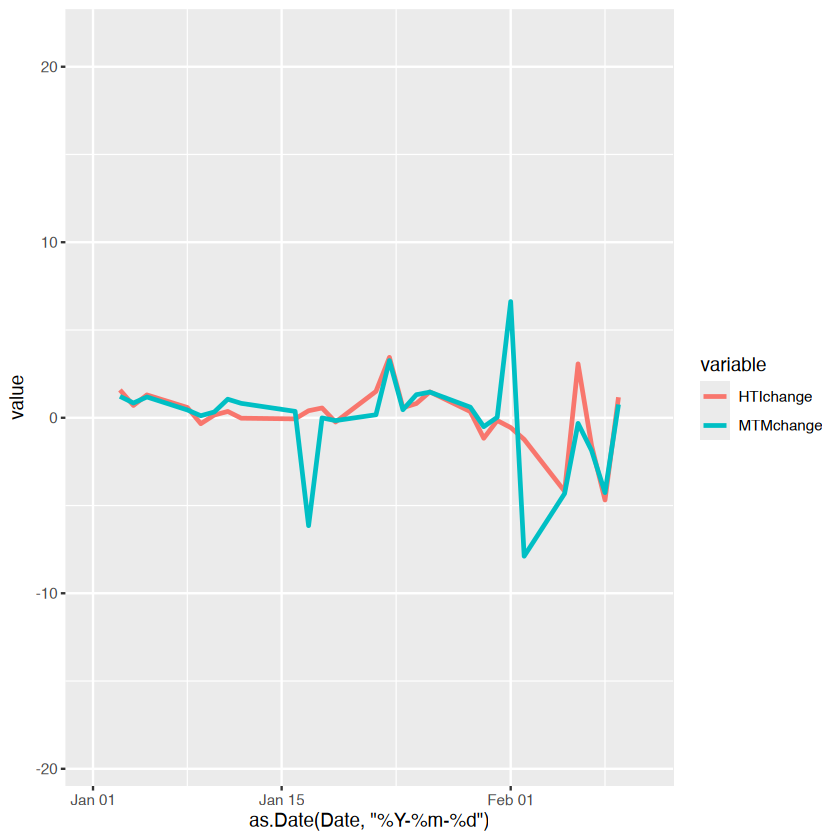

In [15]:
data.frame(Date=Stocks$Date, 
         HTIchange= transmute(Stocks, HTIchange=((HTI-lag(HTI))/lag(HTI))*100), 
        MTMchange = transmute(Stocks, MTMchange=((mark_to_market-lag(mark_to_market))/lag(mark_to_market))*100)) %>%
reshape2::melt(id.vars="Date") %>%
ggplot(aes(x=as.Date(Date,"%Y-%m-%d"), y=value, group=variable, color=variable)) + geom_line(size=1) +
 scale_x_date(limit=c(as.Date("2018-01-01"),as.Date("2018-02-11")))

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”


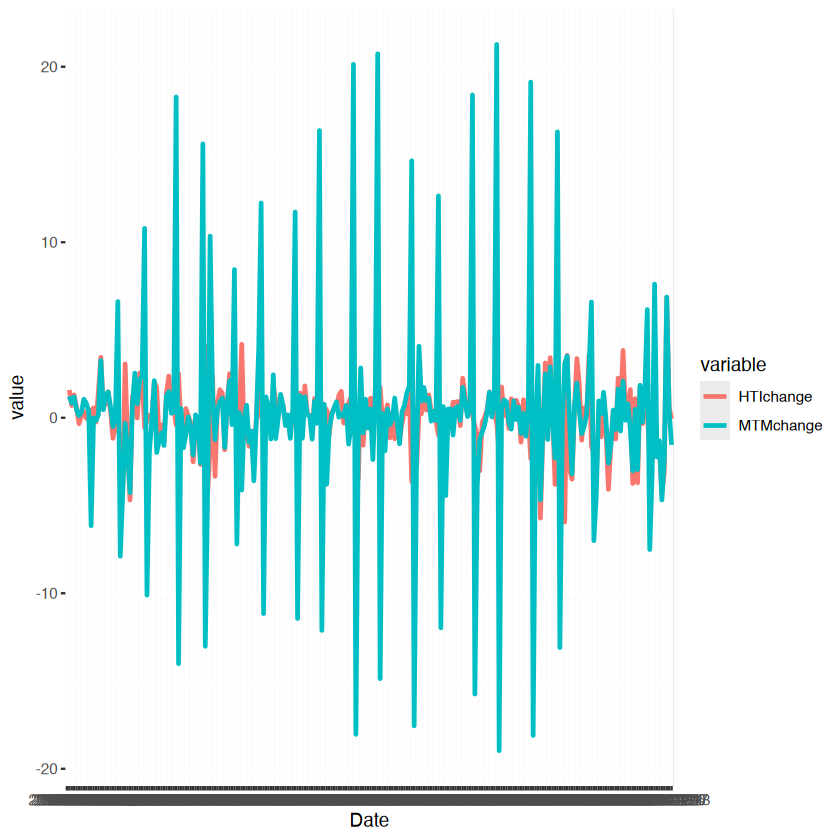

In [16]:
data.frame(Date=Stocks$Date, 
         HTIchange= transmute(Stocks, HTIchange=((HTI-lag(HTI))/lag(HTI))*100), 
        MTMchange = transmute(Stocks, MTMchange=((mark_to_market-lag(mark_to_market))/lag(mark_to_market))*100)) %>%
reshape2::melt(id.vars="Date") %>%
ggplot(aes(x=Date, y=value, group=variable, color=variable)) + geom_line(size=1)

## 8.
Download the USD/JPY 2018 historical data at https://www.myfxbook.com/en/forex-market/currencies/USDJPY-historical-data
(https://www.myfxbook.com/en/forex-market/currencies/USDJPY-historical-data) then use the "Close" column as the rate to convert
your MTM series from USD to JPY. Plot the two MTM curves. You will need to convert to daily percentage change t.oo

In [17]:
USDJPY = read.csv('usdjpy.csv')
usdjpy_close = USDJPY[, c('Date', 'Close')]
usdjpy_close = rename(usdjpy_close, 'JPY_Close' = 'Close')
head(usdjpy_close)

,Date,JPY_Close
,<chr>,<dbl>
1,31-Dec-18,110.330
2,28-Dec-18,110.855
3,27-Dec-18,111.206
4,26-Dec-18,110.402
5,25-Dec-18,110.311
6,24-Dec-18,111.054


In [18]:
# Convert the Date column to a common date format (YYYY-MM-DD) in the jpy_close data frame
usdjpy_close$Date <- as.Date(usdjpy_close$Date, format = "%d-%b-%y")

Stocks$Date <- as.Date(Stocks$Date)

# Merge the data frames after converting the Date column
newStocks <- merge(Stocks, usdjpy_close, by = 'Date')
head(newStocks)

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI,JPY_Close
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.466537,107.530434,85.9499969,79.7929230,53.2500000,53.1195488,43.0649986,40.5689392,59.4505005,⋯,46.6300011,41.7716141,112.389999,99.9559326,21.3686676,21.3686676,178.708557,5000000.00,95.2060707,112.770
2,2018-01-03,151.520081,110.486214,86.3499985,80.1642685,54.1240005,53.9914093,43.0574989,40.5618706,60.2099991,⋯,47.7099991,42.7390900,113.309998,100.7741547,21.1499996,21.1499996,178.708557,5060975.46,96.7151575,112.244
3,2018-01-04,154.588913,112.723938,87.1100006,80.8698120,54.3199997,54.1869278,43.2574997,40.7502708,60.4794998,⋯,48.1800003,43.1601257,115.050003,102.3216553,20.9746666,20.9746666,178.708557,5103484.77,97.3920589,112.607
4,2018-01-05,155.344162,113.274673,88.1900024,81.8724518,55.1114998,54.9764862,43.7500000,41.2142296,61.4570007,⋯,48.4700012,43.4199104,116.330002,103.4600449,21.1053333,21.1053333,178.708557,5163911.86,98.6598013,112.783
5,2018-01-08,156.281067,113.957848,88.2799988,81.9560089,55.3470001,55.2114105,43.5875015,41.0611420,62.3434982,⋯,48.9799995,43.8767662,114.800003,102.0993195,22.4273338,22.4273338,178.708557,5186872.16,99.2376404,113.154
6,2018-01-09,156.625244,114.208839,88.2200012,81.9003296,55.3129997,55.1774940,43.5825005,41.0564423,62.6349983,⋯,49.0600014,44.1195869,114.160004,101.5301208,22.2460003,22.2460003,366.271200,5192835.14,98.9021742,113.141


In [19]:
newStocks$MTM_JPY = newStocks$mark_to_market * newStocks$JPY_Close
head(newStocks)

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI,JPY_Close,MTM_JPY
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.466537,107.530434,85.9499969,79.7929230,53.2500000,53.1195488,43.0649986,40.5689392,59.4505005,⋯,41.7716141,112.389999,99.9559326,21.3686676,21.3686676,178.708557,5000000.00,95.2060707,112.770,563850000
2,2018-01-03,151.520081,110.486214,86.3499985,80.1642685,54.1240005,53.9914093,43.0574989,40.5618706,60.2099991,⋯,42.7390900,113.309998,100.7741547,21.1499996,21.1499996,178.708557,5060975.46,96.7151575,112.244,568064130
3,2018-01-04,154.588913,112.723938,87.1100006,80.8698120,54.3199997,54.1869278,43.2574997,40.7502708,60.4794998,⋯,43.1601257,115.050003,102.3216553,20.9746666,20.9746666,178.708557,5103484.77,97.3920589,112.607,574688109
4,2018-01-05,155.344162,113.274673,88.1900024,81.8724518,55.1114998,54.9764862,43.7500000,41.2142296,61.4570007,⋯,43.4199104,116.330002,103.4600449,21.1053333,21.1053333,178.708557,5163911.86,98.6598013,112.783,582401471
5,2018-01-08,156.281067,113.957848,88.2799988,81.9560089,55.3470001,55.2114105,43.5875015,41.0611420,62.3434982,⋯,43.8767662,114.800003,102.0993195,22.4273338,22.4273338,178.708557,5186872.16,99.2376404,113.154,586915333
6,2018-01-09,156.625244,114.208839,88.2200012,81.9003296,55.3129997,55.1774940,43.5825005,41.0564423,62.6349983,⋯,44.1195869,114.160004,101.5301208,22.2460003,22.2460003,366.271200,5192835.14,98.9021742,113.141,587522560


Warning message:
“Removed 446 rows containing missing values or values outside the scale range
(`geom_line()`).”


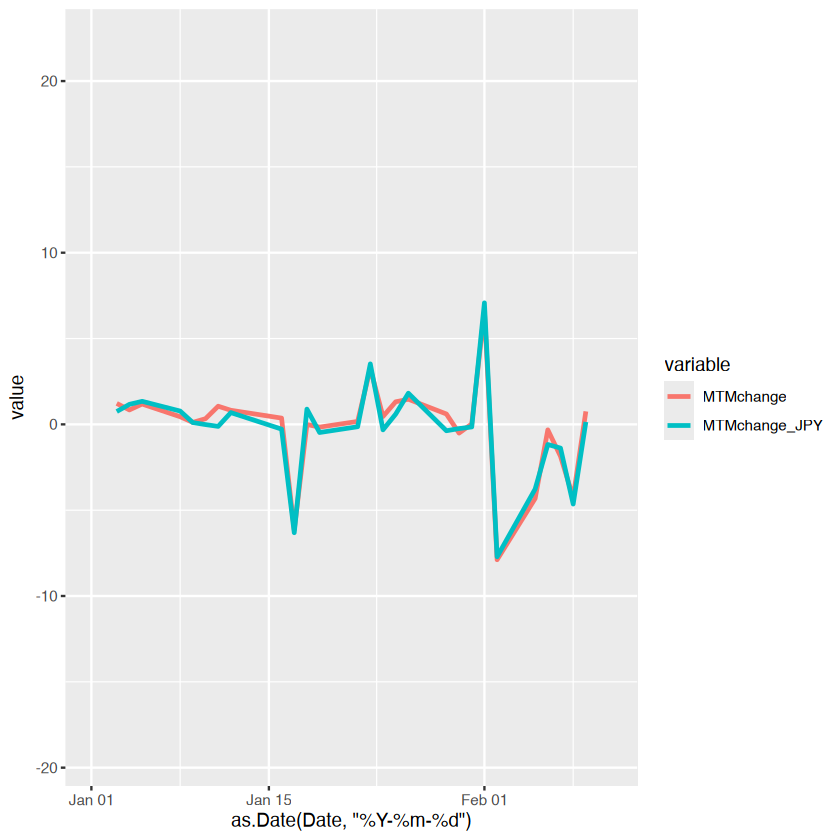

In [20]:
data.frame(Date=newStocks$Date, 
        MTMchange = transmute(newStocks, MTMchange=((mark_to_market-lag(mark_to_market))/lag(mark_to_market))*100),
        MTMchange_JPY = transmute(newStocks, MTMchange_JPY=((MTM_JPY-lag(MTM_JPY))/lag(MTM_JPY))*100))%>%
reshape2::melt(id.vars="Date") %>%
ggplot(aes(x=as.Date(Date,"%Y-%m-%d") , y=value, group=variable, color=variable)) + geom_line(size=1) +
 scale_x_date(limit=c(as.Date("2018-01-01"),as.Date("2018-02-11")))

## 9.
The above two strategies both rebalance every 5 days. Try to change the days interval and find the optimal days interval that
maximizes the MTM on 12/31/2018.

In [21]:
# Create stock split every 8th row
StockSplit_8 <- Stocks[seq(1, nrow(Stocks), 8), ]
StockSplit_8$Date <- as.Date(StockSplit_8$Date)
cat("StockSplit_8\n")
head(StockSplit_8)

# Create stock split every 10th row
StockSplit_10 <- Stocks[seq(1, nrow(Stocks), 10), ]
StockSplit_10$Date <- as.Date(StockSplit_10$Date)
cat("\nStockSplit_10\n")
head(StockSplit_10)

# Create stock split every 12th row
StockSplit_12 <- Stocks[seq(1, nrow(Stocks), 12), ]
StockSplit_12$Date <- as.Date(StockSplit_12$Date)
cat("\nStockSplit_12\n")
head(StockSplit_12)

# Create stock split every 14th row
StockSplit_14 <- Stocks[seq(1, nrow(Stocks), 14), ]
StockSplit_14$Date <- as.Date(StockSplit_14$Date)
cat("\nStockSplit_14\n")
head(StockSplit_14)

StockSplit_8


,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.466537,107.530434,85.9499969,79.7929230,53.2500000,53.1195488,43.0649986,40.5689392,59.4505005,⋯,201.070007,46.6300011,41.7716141,112.389999,99.9559326,21.3686676,21.3686676,178.7085571,5000000.00,95.2060707
9,2018-01-12,155.965576,113.727798,89.5999985,83.1814575,56.1129990,55.9755325,44.2724991,41.7064323,65.2600021,⋯,221.229996,49.5099983,44.5242653,110.129997,97.9459686,22.4146671,22.4146671,366.2712002,5308155.76,99.3865728
17,2018-01-25,158.193115,115.352104,92.3300018,85.7158890,58.5185013,58.3751411,42.7775002,40.2980957,68.8974991,⋯,269.700012,51.5999985,46.4038010,112.839996,100.3561554,22.5093327,22.5093327,89.2742977,5254804.06,106.4845953
25,2018-02-06,148.508606,108.290283,91.3300018,84.7875290,54.0299988,53.8976364,40.7574997,38.3951721,72.1419983,⋯,265.720001,49.4000015,44.4253464,108.360001,96.3717880,22.2646675,22.2646675,231.8664017,5000000.00,103.7822773
33,2018-02-16,149.311661,109.947823,92.0000000,85.8107147,54.7400017,54.6058998,43.1074982,40.7745285,72.4345016,⋯,278.519989,50.7099991,45.6034241,104.900002,93.2945786,22.3659992,22.3659992,191.0532093,5669709.15,104.5449652
41,2018-03-01,147.045883,108.279381,92.8499985,86.6035461,53.4760017,53.3449974,43.7500000,41.3822670,74.6725006,⋯,290.390015,49.7099991,44.7041245,102.000000,90.7154236,22.0620003,22.0620003,228.7144451,4815006.85,105.1896400



StockSplit_10


,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.466537,107.530434,85.9499969,79.7929230,53.2500000,53.1195488,43.0649986,40.5689392,59.4505005,⋯,201.070007,46.6300011,41.7716141,112.389999,99.9559326,21.3686676,21.3686676,178.708557,5000000.00,95.2060707
11,2018-01-17,161.233276,117.568932,90.1399994,83.6827774,56.5989990,56.4603424,44.7750015,42.1798172,64.7500000,⋯,217.500000,50.2700005,45.2077408,111.190002,98.8887024,23.1439991,23.1439991,185.800730,5000000.00,99.7201284
21,2018-01-31,156.500961,114.118195,95.0100021,88.2038803,58.4970016,58.3536949,41.8574982,39.4314232,72.5445023,⋯,270.299988,51.5900002,46.3948021,113.250000,100.7207947,23.6206665,23.6206665,149.781870,5338091.16,107.0060619
31,2018-02-14,147.954117,108.948181,90.8099976,84.7007904,53.4850006,53.3539734,41.8424988,39.5779953,72.5524979,⋯,266.000000,49.4500008,44.4703140,105.129997,93.4991302,21.4873333,21.4873333,191.053209,4997632.16,102.8231447
41,2018-03-01,147.045883,108.279381,92.8499985,86.6035461,53.4760017,53.3449974,43.7500000,41.3822670,74.6725006,⋯,290.390015,49.7099991,44.7041245,102.000000,90.7154236,22.0620003,22.0620003,228.714445,4815006.85,105.1896400
51,2018-03-15,152.590820,112.362480,94.1800003,87.8440704,57.4790001,57.3381882,44.6624985,42.2453766,79.1159973,⋯,321.089996,52.3699989,47.0962563,108.489998,96.4874115,21.7066669,21.7066669,346.776794,4953200.05,111.5544977



StockSplit_12


,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.466537,107.530434,85.9499969,79.7929230,53.2500000,53.1195488,43.0649986,40.5689392,59.4505005,⋯,201.070007,46.6300011,41.7716141,112.389999,99.9559326,21.3686676,21.3686676,178.708557,5000000.00,95.2060707
13,2018-01-19,155.229446,113.191032,90.0000000,83.5527878,56.8754997,56.7361641,44.6150017,42.0290947,64.7289963,⋯,220.460007,50.5800018,45.4865150,113.199997,100.6763306,23.3346672,23.3346672,395.955652,4991485.79,100.0313610
25,2018-02-06,148.508606,108.290283,91.3300018,84.7875290,54.0299988,53.8976364,40.7574997,38.3951721,72.1419983,⋯,265.720001,49.4000015,44.4253464,108.360001,96.3717880,22.2646675,22.2646675,231.866402,5000000.00,103.7822773
37,2018-02-23,148.680695,109.483200,94.0599976,87.7321320,56.3395004,56.2014809,43.8750000,41.5004959,75.0000000,⋯,285.929993,50.5000000,45.4145813,104.900002,93.2945786,23.4699993,23.4699993,132.945940,5100840.10,106.6045179
49,2018-03-13,152.313583,112.158371,94.4100037,88.0586090,56.9085007,56.7690849,44.9925003,42.5575142,79.4089966,⋯,315.880005,52.5800018,47.2851181,107.620003,95.7136612,22.7893333,22.7893333,113.390999,5000000.00,110.8782932
61,2018-03-29,146.682602,108.011887,91.2699966,85.1298294,51.5895004,51.4631157,41.9449997,39.6749496,72.3669968,⋯,295.350006,45.7500000,41.1429138,105.160004,93.5258179,17.7420006,17.7420006,108.366993,5063103.78,102.7646099



StockSplit_14


,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-01-02,147.466537,107.530434,85.9499969,79.7929230,53.2500000,53.1195488,43.0649986,40.5689392,59.4505005,⋯,201.070007,46.6300011,41.7716141,112.389999,99.9559326,21.3686676,21.3686676,178.7085571,5000000.00,95.2060707
15,2018-01-23,158.938812,115.895836,91.9000015,85.3166885,58.4985008,58.3551903,44.2599983,41.6946602,68.1269989,⋯,250.289993,51.1199989,45.9721413,114.269997,101.6279449,23.5193329,23.5193329,395.9556522,5162953.86,105.0273640
29,2018-02-12,144.741867,106.582771,89.1299973,82.7451096,52.5970001,52.4681473,40.6775017,38.4760399,69.3115005,⋯,257.950012,48.1500015,43.3012199,102.750000,91.3824539,21.0486679,21.0486679,53.7553272,4853476.45,100.2766552
43,2018-03-05,150.047806,110.489891,93.6399994,87.3403778,54.5465012,54.4128723,44.2050018,41.8126411,76.1804962,⋯,315.000000,51.2900009,46.1250267,104.599998,93.0277710,22.2233334,22.2233334,228.7144451,4947989.74,109.2133131
57,2018-03-23,142.342255,104.815819,87.1800003,81.3150101,51.0784988,50.9533653,41.2350006,39.0033722,74.7779999,⋯,300.940002,44.7900009,40.2795792,102.480003,91.1423111,20.1026669,20.1026669,246.6620750,5423394.96,102.4316427
71,2018-04-13,149.818359,110.320938,93.0800018,86.8180695,51.4635010,51.3374252,43.6824989,41.3184090,71.5394974,⋯,311.649994,46.0800018,41.4396706,108.129997,96.1672287,20.0226669,20.0226669,359.7195320,5200175.97,105.9986523


In [22]:
# 8 days
# Set initial variables
options(digits = 9)
total_investment = 5000000
remaining_cash = total_investment
investment_split = total_investment / 8  # Rebalancing interval to 8 days
mark_to_market = 0
begin_date = mdy('01/02/2018')
start_date = begin_date
end_date = mdy('12/31/2018')
AllStocks = c('IBM_AdjClose', 'MSFT_AdjClose', 'GOOG_AdjClose', 'AAPL_AdjClose', 'AMZN_AdjClose', 'META_AdjClose', 'NFLX_AdjClose', 'TSLA_AdjClose', 'ORCL_AdjClose', 'SAP_AdjClose')
IntialStocks = c('IBM_Close', 'MSFT_Close', 'GOOG_Close', 'AAPL_Close', 'AMZN_Close')
SharesCount = list()
Strategy_8 = data.frame()  # Data frame for storing strategy results

while (start_date <= end_date) {
    if (start_date == '2018-01-02') {
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            b = floor(investment_split / a[i])
            SharesCount[i] = b[[i]]
            remaining_cash = remaining_cash - b * a[i]
            mark_to_market = mark_to_market + b * a[i]
        }
        colnames(remaining_cash) = 'remaining_cash'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
    
        colnames(mark_to_market) = 'mark_to_market'
        mark_to_market = mark_to_market + remaining_cash
    
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
    } else if (start_date %in% StockSplit_8$Date) {  # Rebalancing every 8 days
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            mark_to_market = mark_to_market + SharesCount[[i]] * a[i]
        }
        total_investment = mark_to_market + remaining_cash
    
        remaining_cash = total_investment
        investment_split = total_investment / 8  # Adjust split for rebalancing every 8 days
        colnames(total_investment) = 'total_investment'
        colnames(mark_to_market) = 'mark_to_market'
        calculated_stocks = list()
        for (i in AllStocks) {
            x = Stocks[Stocks$Date == start_date, AllStocks]
            y = Stocks[Stocks$Date == begin_date, AllStocks]
            percent_change = 100 * ((x[i] - y[i]) / y[i])
            col = paste0(i, "_PC")
            calculated_stocks[col] = percent_change
        }
        calculated_stocks = calculated_stocks[order(unlist(calculated_stocks))]
        calculated_stocks = tail(calculated_stocks, 5)

        # Update the list of initial stocks based on performance
        initial_col_list = names(calculated_stocks)
        initial_col_list = sub('_.*', '', initial_col_list)
        initial_col_list = paste0(initial_col_list, '_Close')
        IntialStocks = initial_col_list
        SharesCount = list()
        b = list()
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            b = floor(investment_split[, 1] / a[i])
            SharesCount[i] = b[[i]]
            remaining_cash = remaining_cash - b * a[i]
            mark_to_market = mark_to_market + b * a[i]
        }
        mark_to_market = mark_to_market + remaining_cash
    
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
    
    } 
    # No rebalancing, just calculate mark to market value
    else {
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            mark_to_market = mark_to_market + SharesCount[[i]] * a[i]
        }
        colnames(mark_to_market) = 'mark_to_market'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
    
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
    }

    # Move to the next day
    start_date = start_date + 1
}

# Store the final strategy results
Strategy_8 = data.frame('Strategy_8', mark_to_market = tail(Stocks$mark_to_market, 1))

# Calculate the profit or loss
output_8 = c('Profit', 5000000 - tail(Stocks$mark_to_market, 1))

# Output the final results
Strategy_8
output_8
tail(Stocks)

profit_8 <- 5000000 - tail(Stocks$mark_to_market, 1)

X.Strategy_8.,mark_to_market
<chr>,<dbl>
Strategy_8,3151289.58


[1] "Profit"          "1848710.4182396"

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
245,2018-12-20,108.049713,82.3520050,101.5100021,95.8696518,50.4705009,50.3468590,39.2075005,37.4895210,73.0414963,⋯,260.579987,46.2400017,42.0882912,100.0999985,90.3883514,21.0253334,21.0253334,1953666.20,3064323.68,93.3624527
246,2018-12-21,106.061188,80.8364334,98.2300034,92.7718964,48.9770012,48.8570175,37.6824989,36.0313454,68.8724976,⋯,246.389999,44.0000000,40.0494232,96.1399994,86.8125458,21.3180008,21.3180008,1953666.20,2951972.24,89.2621185
247,2018-12-24,102.839386,78.3808670,94.1299973,88.8997116,48.8110008,48.6914253,36.7075005,35.0990677,67.1979980,⋯,233.880005,42.6899986,38.8570290,95.0000000,85.7831573,19.6926670,19.6926670,1953666.20,2820858.25,86.5008551
248,2018-12-26,106.491394,81.1642990,100.5599976,94.9724579,51.9729996,51.8456764,39.2924995,37.5708008,73.5449982,⋯,253.669998,44.5900002,40.5864449,98.3799973,88.8352127,21.7393322,21.7393322,1953666.20,3041761.98,92.4421209
249,2018-12-27,108.776291,82.9057846,101.1800003,95.5579910,52.1940002,52.0661354,39.0374985,37.3269844,73.0820007,⋯,255.570007,44.9700012,40.9323349,98.9899979,89.3860397,21.0753326,21.0753326,1870657.46,4987659.98,92.9395134
250,2018-12-28,108.059273,82.3593063,100.3899994,94.8118668,51.8540001,51.7269669,39.0574989,37.3460960,73.9010010,⋯,256.079987,44.8199997,40.7957916,99.1999969,89.5756683,22.2579994,22.2579994,1870657.46,3151289.58,92.8819752


In [23]:
#10 days

options(digits = 9)
total_investment = 5000000
remaining_cash = total_investment
investment_split = total_investment / 10  # Adjusting rebalancing interval to 10 days
mark_to_market = 0
begin_date = mdy('01/02/2018')
start_date = begin_date
end_date = mdy('12/31/2018')
AllStocks = c('IBM_AdjClose', 'MSFT_AdjClose', 'GOOG_AdjClose', 'AAPL_AdjClose', 'AMZN_AdjClose', 'META_AdjClose', 'NFLX_AdjClose', 'TSLA_AdjClose', 'ORCL_AdjClose', 'SAP_AdjClose')
IntialStocks = c('IBM_Close', 'MSFT_Close', 'GOOG_Close', 'AAPL_Close', 'AMZN_Close')
SharesCount = list()
Strategy_10 = data.frame()  # Create a empty data frame for storing strategy results

while (start_date <= end_date) {
    if (start_date == '2018-01-02') {
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            b = floor(investment_split / a[i])
            SharesCount[i] = b[[i]]
            remaining_cash = remaining_cash - b * a[i]
            mark_to_market = mark_to_market + b * a[i]
        }
        colnames(remaining_cash) = 'remaining_cash'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
        colnames(mark_to_market) = 'mark_to_market'
        mark_to_market = mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
    } else if (start_date %in% StockSplit_10$Date) {  # Rebalancing 10 days
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            mark_to_market = mark_to_market + SharesCount[[i]] * a[i]
        }
        total_investment = mark_to_market + remaining_cash
        remaining_cash = total_investment
    
        investment_split = total_investment/ 10  # Setting rebalancing interval to 10 days
        colnames(total_investment) = 'total_investment'
        colnames(mark_to_market) = 'mark_to_market'
        calculated_stocks = list()
        for (i in AllStocks) {
            x = Stocks[Stocks$Date == start_date, AllStocks]
            y = Stocks[Stocks$Date == begin_date, AllStocks]
            percent_change = 100 * ((x[i] - y[i]) / y[i])
            col = paste0(i, "_PC")
            calculated_stocks[col] = percent_change
        }
        calculated_stocks = calculated_stocks[order(unlist(calculated_stocks))]
        calculated_stocks = tail(calculated_stocks, 5)
        initial_col_list = names(calculated_stocks)
        initial_col_list = sub('_.*', '', initial_col_list)
        initial_col_list = paste0(initial_col_list, '_Close')
        IntialStocks = initial_col_list
        SharesCount = list()
        b = list()
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            b = floor(investment_split[, 1] / a[i])
            SharesCount[i] = b[[i]]
            remaining_cash = remaining_cash - b * a[i]
            mark_to_market = mark_to_market + b * a[i]
        }
        mark_to_market = mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
    } else {
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            mark_to_market = mark_to_market + SharesCount[[i]] * a[i]
        }
        colnames(mark_to_market) = 'mark_to_market'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
    }
    start_date = start_date + 1
}

Strategy_10 = data.frame('Strategy_10', mark_to_market = tail(Stocks$mark_to_market, 1))
output_10 = c('Profit', 5000000 - tail(Stocks$mark_to_market, 1))
Strategy_10
output_10
tail(Stocks)

profit_10 <- 5000000 - tail(Stocks$mark_to_market, 1)

X.Strategy_10.,mark_to_market
<chr>,<dbl>
Strategy_10,2394217.73


[1] "Profit"           "2605782.27468872"

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
245,2018-12-20,108.049713,82.3520050,101.5100021,95.8696518,50.4705009,50.3468590,39.2075005,37.4895210,73.0414963,⋯,260.579987,46.2400017,42.0882912,100.0999985,90.3883514,21.0253334,21.0253334,2542270.11,2392458.53,93.3624527
246,2018-12-21,106.061188,80.8364334,98.2300034,92.7718964,48.9770012,48.8570175,37.6824989,36.0313454,68.8724976,⋯,246.389999,44.0000000,40.0494232,96.1399994,86.8125458,21.3180008,21.3180008,2542270.11,2304739.18,89.2621185
247,2018-12-24,102.839386,78.3808670,94.1299973,88.8997116,48.8110008,48.6914253,36.7075005,35.0990677,67.1979980,⋯,233.880005,42.6899986,38.8570290,95.0000000,85.7831573,19.6926670,19.6926670,2542270.11,2202373.61,86.5008551
248,2018-12-26,106.491394,81.1642990,100.5599976,94.9724579,51.9729996,51.8456764,39.2924995,37.5708008,73.5449982,⋯,253.669998,44.5900002,40.5864449,98.3799973,88.8352127,21.7393322,21.7393322,2542270.11,2374843.33,92.4421209
249,2018-12-27,108.776291,82.9057846,101.1800003,95.5579910,52.1940002,52.0661354,39.0374985,37.3269844,73.0820007,⋯,255.570007,44.9700012,40.9323349,98.9899979,89.3860397,21.0753326,21.0753326,2542270.11,2368778.07,92.9395134
250,2018-12-28,108.059273,82.3593063,100.3899994,94.8118668,51.8540001,51.7269669,39.0574989,37.3460960,73.9010010,⋯,256.079987,44.8199997,40.7957916,99.1999969,89.5756683,22.2579994,22.2579994,2542270.11,2394217.73,92.8819752


In [24]:
# 12 days

options(digits = 9)
total_investment = 5000000
remaining_cash = total_investment
investment_split = total_investment / 12  # Setting rebalancing interval to 12 days
mark_to_market = 0
begin_date = mdy('01/02/2018')
start_date = begin_date
end_date = mdy('12/31/2018')
AllStocks = c('IBM_AdjClose', 'MSFT_AdjClose', 'GOOG_AdjClose', 'AAPL_AdjClose', 'AMZN_AdjClose', 'META_AdjClose', 'NFLX_AdjClose', 'TSLA_AdjClose', 'ORCL_AdjClose', 'SAP_AdjClose')
IntialStocks = c('IBM_Close', 'MSFT_Close', 'GOOG_Close', 'AAPL_Close', 'AMZN_Close')
SharesCount = list()
Strategy_12 = data.frame()  # Create a empty data frame for storing strategy results

while (start_date <= end_date) {
    if (start_date == '2018-01-02') {
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            b = floor(investment_split / a[i])
            SharesCount[i] = b[[i]]
            remaining_cash = remaining_cash - b * a[i]
            mark_to_market = mark_to_market + b * a[i]
        }
        colnames(remaining_cash) = 'remaining_cash'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
        colnames(mark_to_market) = 'mark_to_market'
        mark_to_market = mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
    } else if (start_date %in% StockSplit_12$Date) {  # Rebalancing 12 days
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            mark_to_market = mark_to_market + SharesCount[[i]] * a[i]
        }
        total_investment = mark_to_market + remaining_cash
        remaining_cash = total_investment
        investment_split = total_investment / 12  # Setting rebalancing interval to 12 days
        colnames(total_investment) = 'total_investment'
        colnames(mark_to_market) = 'mark_to_market'
        calculated_stocks = list()
        for (i in AllStocks) {
            x = Stocks[Stocks$Date == start_date, AllStocks]
            y = Stocks[Stocks$Date == begin_date, AllStocks]
            percent_change = 100 * ((x[i] - y[i]) / y[i])
            col = paste0(i, "_PC")
            calculated_stocks[col] = percent_change
        }
        calculated_stocks = calculated_stocks[order(unlist(calculated_stocks))]
        calculated_stocks = tail(calculated_stocks, 5)
        initial_col_list = names(calculated_stocks)
        initial_col_list = sub('_.*', '', initial_col_list)
        initial_col_list = paste0(initial_col_list, '_Close')
        IntialStocks = initial_col_list
        SharesCount = list()
        b = list()
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            b = floor(investment_split[, 1] / a[i])
            SharesCount[i] = b[[i]]
            remaining_cash = remaining_cash - b * a[i]
            mark_to_market = mark_to_market + b * a[i]
        }
        mark_to_market = mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
    } else {
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            mark_to_market = mark_to_market + SharesCount[[i]] * a[i]
        }
        colnames(mark_to_market) = 'mark_to_market'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
    }
    start_date = start_date + 1
}

Strategy_12 = data.frame('Strategy_12', mark_to_market = tail(Stocks$mark_to_market, 1))
output_12 = c('Profit', 5000000 - tail(Stocks$mark_to_market, 1))
Strategy_12
output_12
tail(Stocks)

profit_12 <- 5000000 - tail(Stocks$mark_to_market, 1)

X.Strategy_12.,mark_to_market
<chr>,<dbl>
Strategy_12,2041748.9


[1] "Profit"           "2958251.10313416"

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
245,2018-12-20,108.049713,82.3520050,101.5100021,95.8696518,50.4705009,50.3468590,39.2075005,37.4895210,73.0414963,⋯,260.579987,46.2400017,42.0882912,100.0999985,90.3883514,21.0253334,21.0253334,3035472.29,2040244.83,93.3624527
246,2018-12-21,106.061188,80.8364334,98.2300034,92.7718964,48.9770012,48.8570175,37.6824989,36.0313454,68.8724976,⋯,246.389999,44.0000000,40.0494232,96.1399994,86.8125458,21.3180008,21.3180008,3035472.29,1965443.66,89.2621185
247,2018-12-24,102.839386,78.3808670,94.1299973,88.8997116,48.8110008,48.6914253,36.7075005,35.0990677,67.1979980,⋯,233.880005,42.6899986,38.8570290,95.0000000,85.7831573,19.6926670,19.6926670,3035472.29,1878148.32,86.5008551
248,2018-12-26,106.491394,81.1642990,100.5599976,94.9724579,51.9729996,51.8456764,39.2924995,37.5708008,73.5449982,⋯,253.669998,44.5900002,40.5864449,98.3799973,88.8352127,21.7393322,21.7393322,3035472.29,2025227.16,92.4421209
249,2018-12-27,108.776291,82.9057846,101.1800003,95.5579910,52.1940002,52.0661354,39.0374985,37.3269844,73.0820007,⋯,255.570007,44.9700012,40.9323349,98.9899979,89.3860397,21.0753326,21.0753326,3035472.29,2020052.98,92.9395134
250,2018-12-28,108.059273,82.3593063,100.3899994,94.8118668,51.8540001,51.7269669,39.0574989,37.3460960,73.9010010,⋯,256.079987,44.8199997,40.7957916,99.1999969,89.5756683,22.2579994,22.2579994,3035472.29,2041748.90,92.8819752


In [25]:
# 14 days

options(digits = 9)
total_investment = 5000000
remaining_cash = total_investment
investment_split = total_investment / 14  # Setting rebalancing interval to 14 days
mark_to_market = 0
begin_date = mdy('01/02/2018')
start_date = begin_date
end_date = mdy('12/31/2018')
AllStocks = c('IBM_AdjClose', 'MSFT_AdjClose', 'GOOG_AdjClose', 'AAPL_AdjClose', 'AMZN_AdjClose', 'META_AdjClose', 'NFLX_AdjClose', 'TSLA_AdjClose', 'ORCL_AdjClose', 'SAP_AdjClose')
IntialStocks = c('IBM_Close', 'MSFT_Close', 'GOOG_Close', 'AAPL_Close', 'AMZN_Close')
SharesCount = list()
Strategy_14 = data.frame()  # Create a empty data frame for storing the strategy results

while (start_date <= end_date) {
    if (start_date == '2018-01-02') {
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            b = floor(investment_split / a[i])
            SharesCount[i] = b[[i]]
            remaining_cash = remaining_cash - b * a[i]
            mark_to_market = mark_to_market + b * a[i]
        }
        colnames(remaining_cash) = 'remaining_cash'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
        colnames(mark_to_market) = 'mark_to_market'
        mark_to_market = mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
    } else if (start_date %in% StockSplit_14$Date) {  # Rebalancing 14 days
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            mark_to_market = mark_to_market + SharesCount[[i]] * a[i]
        }
        total_investment = mark_to_market + remaining_cash
        remaining_cash = total_investment
        investment_split = total_investment / 14  # Setting rebalancing interval to 14 days
        colnames(total_investment) = 'total_investment'
        colnames(mark_to_market) = 'mark_to_market'
        calculated_stocks = list()
        for (i in AllStocks) {
            x = Stocks[Stocks$Date == start_date, AllStocks]
            y = Stocks[Stocks$Date == begin_date, AllStocks]
            percent_change = 100 * ((x[i] - y[i]) / y[i])
            col = paste0(i, "_PC")
            calculated_stocks[col] = percent_change
        }
        calculated_stocks = calculated_stocks[order(unlist(calculated_stocks))]
        calculated_stocks = tail(calculated_stocks, 5)
        initial_col_list = names(calculated_stocks)
        initial_col_list = sub('_.*', '', initial_col_list)
        initial_col_list = paste0(initial_col_list, '_Close')
        IntialStocks = initial_col_list
        SharesCount = list()
        b = list()
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            b = floor(investment_split[, 1] / a[i])
            SharesCount[i] = b[[i]]
            remaining_cash = remaining_cash - b * a[i]
            mark_to_market = mark_to_market + b * a[i]
        }
        mark_to_market = mark_to_market + remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
    } else {
        mark_to_market = 0
        for (i in IntialStocks) {
            a = Stocks[Stocks$Date == start_date, IntialStocks]
            mark_to_market = mark_to_market + SharesCount[[i]] * a[i]
        }
        colnames(mark_to_market) = 'mark_to_market'
        Stocks[Stocks$Date == start_date, 'remaining_cash'] = remaining_cash
        Stocks[Stocks$Date == start_date, 'mark_to_market'] = mark_to_market
    }
    start_date = start_date + 1
}

Strategy_14 = data.frame('Strategy_14', mark_to_market = tail(Stocks$mark_to_market, 1))
output_14 = c('Profit', 5000000 - tail(Stocks$mark_to_market, 1))
Strategy_14
output_14
tail(Stocks)

profit_14 <- 5000000 - tail(Stocks$mark_to_market, 1)

X.Strategy_14.,mark_to_market
<chr>,<dbl>
Strategy_14,1678937.65


[1] "Profit"           "3321062.34860611"

,Date,IBM_Close,IBM_AdjClose,MSFT_Close,MSFT_AdjClose,GOOG_Close,GOOG_AdjClose,AAPL_Close,AAPL_AdjClose,AMZN_Close,⋯,NFLX_AdjClose,ORCL_Close,ORCL_AdjClose,SAP_Close,SAP_AdjClose,TSLA_Close,TSLA_AdjClose,remaining_cash,mark_to_market,HTI
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
245,2018-12-20,108.049713,82.3520050,101.5100021,95.8696518,50.4705009,50.3468590,39.2075005,37.4895210,73.0414963,⋯,260.579987,46.2400017,42.0882912,100.0999985,90.3883514,21.0253334,21.0253334,3286916.51,1677429.97,93.3624527
246,2018-12-21,106.061188,80.8364334,98.2300034,92.7718964,48.9770012,48.8570175,37.6824989,36.0313454,68.8724976,⋯,246.389999,44.0000000,40.0494232,96.1399994,86.8125458,21.3180008,21.3180008,3286916.51,1616392.25,89.2621185
247,2018-12-24,102.839386,78.3808670,94.1299973,88.8997116,48.8110008,48.6914253,36.7075005,35.0990677,67.1979980,⋯,233.880005,42.6899986,38.8570290,95.0000000,85.7831573,19.6926670,19.6926670,3286916.51,1544311.82,86.5008551
248,2018-12-26,106.491394,81.1642990,100.5599976,94.9724579,51.9729996,51.8456764,39.2924995,37.5708008,73.5449982,⋯,253.669998,44.5900002,40.5864449,98.3799973,88.8352127,21.7393322,21.7393322,3286916.51,1665219.00,92.4421209
249,2018-12-27,108.776291,82.9057846,101.1800003,95.5579910,52.1940002,52.0661354,39.0374985,37.3269844,73.0820007,⋯,255.570007,44.9700012,40.9323349,98.9899979,89.3860397,21.0753326,21.0753326,3286916.51,1660796.46,92.9395134
250,2018-12-28,108.059273,82.3593063,100.3899994,94.8118668,51.8540001,51.7269669,39.0574989,37.3460960,73.9010010,⋯,256.079987,44.8199997,40.7957916,99.1999969,89.5756683,22.2579994,22.2579994,3286916.51,1678937.65,92.8819752


In [26]:
# Now print the results for each strategy above
cat("Strategy for an 8-day rebalancing interval:\n")
cat("Profit: $", format(profit_8, big.mark = ",", scientific = FALSE), "\n\n")

cat("Strategy for an 10-day rebalancing interval:\n")
cat("Profit: $", format(profit_10, big.mark = ",", scientific = FALSE), "\n\n")

cat("Strategy for a 12-day rebalancing interval:\n")
cat("Profit: $", format(profit_12, big.mark = ",", scientific = FALSE), "\n\n")

cat("Strategy for an 14-day rebalancing interval:\n")
cat("Profit: $", format(profit_14, big.mark = ",", scientific = FALSE), "\n\n")

Strategy for an 8-day rebalancing interval:
Profit: $ 1,848,710.42 

Strategy for an 10-day rebalancing interval:
Profit: $ 2,605,782.27 

Strategy for a 12-day rebalancing interval:
Profit: $ 2,958,251.1 

Strategy for an 14-day rebalancing interval:
Profit: $ 3,321,062.35 



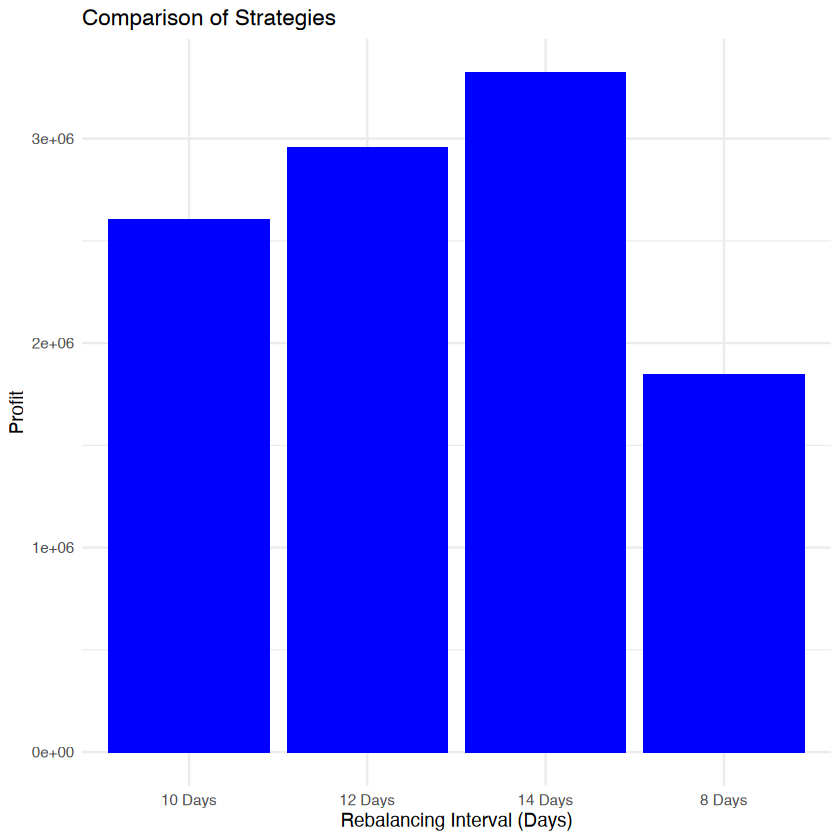

In [27]:
# Create a data frame for strategy comparison
strategy_data <- data.frame(
  Strategy = c('8 Days', '10 Days', '12 Days', '14 Days'),
  Profit = c(profit_8, profit_10, profit_12, profit_14)
)

# Load the ggplot2 library for plotting
library(ggplot2)

# Create the bar plot for strategy comparison
ggplot(data = strategy_data, aes(x = Strategy, y = Profit)) +
  geom_bar(stat = "identity", fill = "blue") +
  labs(title = "Comparison of Strategies",
       x = "Rebalancing Interval (Days)",
       y = "Profit") +
  theme_minimal()